In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/ia/diabetic_data.csv",
    header=None
)

print("Dimensiones del dataset:")
print(data.shape)

data.head()

Dimensiones del dataset:
(101767, 50)


/tmp/ipykernel_4133/3900298820.py:1: DtypeWarning: Columns (0,1,6,7,8,9,12,13,14,15,16,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Se observa información general del dataset
print(data.info())

# Se muestran estadísticas básicas
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101767 entries, 0 to 101766
Data columns (total 50 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       101767 non-null  object
 1   1       101767 non-null  object
 2   2       101767 non-null  object
 3   3       101767 non-null  object
 4   4       101767 non-null  object
 5   5       101767 non-null  object
 6   6       101767 non-null  object
 7   7       101767 non-null  object
 8   8       101767 non-null  object
 9   9       101767 non-null  object
 10  10      101767 non-null  object
 11  11      101767 non-null  object
 12  12      101767 non-null  object
 13  13      101767 non-null  object
 14  14      101767 non-null  object
 15  15      101767 non-null  object
 16  16      101767 non-null  object
 17  17      101767 non-null  object
 18  18      101767 non-null  object
 19  19      101767 non-null  object
 20  20      101767 non-null  object
 21  21      101767 non-null  object
 

In [ ]:
X = data.iloc[1:, [9, 12, 13, 14, 15, 16, 17]].values

# Variable objetivo (y) - La última de todas
y = (data.iloc[1:, 49] == '<30').astype(int).values

print("Variables de entrada (X):", X.shape)
print("Variable objetivo (y):", y.shape)

Variables de entrada (X): (101766, 7)
Variable objetivo (y): (101766,)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Datos normalizados (primeras 2 filas):")
print(X_scaled[:2])

Datos normalizados (primeras 2 filas):
[[-1.13764856 -0.10651686 -0.78539774 -1.84826769 -0.29146149 -0.21262018
  -0.50327619]
 [-0.46765271  0.80838387 -0.78539774  0.24338965 -0.29146149 -0.21262018
  -0.50327619]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print("Datos entrenamiento (X):", X_train.shape)
print("Datos prueba (X):", X_test.shape)

Datos entrenamiento (X): (81412, 7)
Datos prueba (X): (20354, 7)


In [ ]:
class DiabeticDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

train_dataset = DiabeticDataset(X_train, y_train)
test_dataset  = DiabeticDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class RegresionLogistica(nn.Module):
    def __init__(self, input_size):
        super(RegresionLogistica, self).__init__()
        self.fc = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc(x))

model = RegresionLogistica(X_train.shape[1]).to(device)

In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 100
best_acc = 0
PATH = "./checkpoint_diabetic.pt"
cost_history = []

for epoch in range(1, epochs + 1):
    model.train()
    losses = []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_b), y_b)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    cost_history.append(np.mean(losses))

    # checkpoint
    model.eval()
    with torch.no_grad():
        preds = (model(torch.from_numpy(X_test).to(device)) >= 0.5).float().cpu().numpy()
    acc = np.mean(preds.flatten() == y_test)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), PATH)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}  loss: {np.mean(cost_history):.4f}  acc: {acc*100:.2f}%")

model.load_state_dict(torch.load(PATH))
print(f"\nMejor accuracy: {best_acc*100:.2f}%")

Epoch 10/100  loss: 0.3755  acc: 88.74%
Epoch 20/100  loss: 0.3569  acc: 88.73%
Epoch 30/100  loss: 0.3509  acc: 88.73%
Epoch 40/100  loss: 0.3478  acc: 88.73%
Epoch 50/100  loss: 0.3459  acc: 88.73%
Epoch 60/100  loss: 0.3446  acc: 88.73%
Epoch 70/100  loss: 0.3438  acc: 88.73%
Epoch 80/100  loss: 0.3432  acc: 88.72%
Epoch 90/100  loss: 0.3427  acc: 88.75%
Epoch 100/100  loss: 0.3422  acc: 88.73%

Mejor accuracy: 88.75%


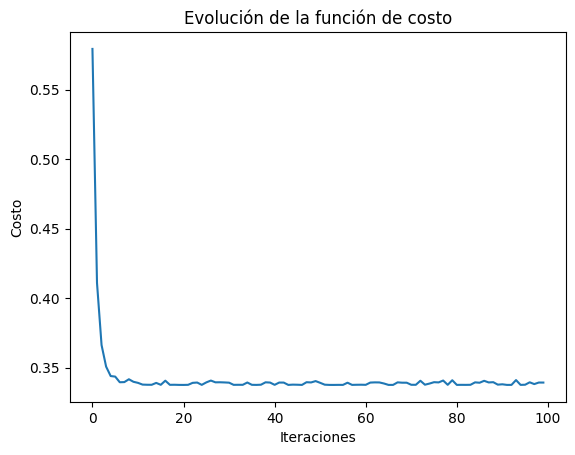

In [ ]:
plt.plot(cost_history)
plt.title("Evolución de la función de costo")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    preds = (model(torch.from_numpy(X_test).to(device)) >= 0.5).float().cpu().numpy()

accuracy = np.mean(preds.flatten() == y_test)
print(f"Precisión del modelo: {accuracy * 100:.2f} %")

Precisión del modelo: 88.75 %
